In [1]:
import sys
sys.path.append('../')
from utils_models import *



# debugging start


In [2]:
max_ql = 30
max_ol = 75
EJ = 3
EC = EJ/4
EL = EJ/20.5
Er = 8.46111172

g = 0.2
w_d =8.460155465243822
amp = 0.003

tot_time =700

system =  FluxoniumOscillatorSystem(
                EJ = EJ,
                EC = EC,
                EL = EL,
                Er = Er,
                g_strength = g,
                qubit_level = max_ql,
                osc_level = max_ol,
                products_to_keep=[[ql, ol] for ql in [0,1,2] for ol in range(max_ol) ],
                computaional_states = '1,2',
                )


In [36]:
lind_pre_trunc = qutip.lindblad_dissipator(system.a_trunc)
lind_pre_trunc

Quantum object: dims = [[[225], [225]], [[225], [225]]], shape = (50625, 50625), type = super, isherm = False
Qobj data =
  (0, 0)	(-3.046604660740256e-06+0j)
  (0, 2)	(4.232610717241356e-07+0j)
  (0, 4)	(0.0008722508035915611+0j)
  (0, 6)	(3.871015500543491e-05+0j)
  (0, 8)	(5.000962303436653e-07+0j)
  (0, 10)	(-1.4722809395421442e-08+0j)
  (0, 12)	(4.344505863125603e-09+0j)
  (0, 14)	(-2.6775137831118452e-11+0j)
  (0, 16)	(1.4542706135280716e-11+0j)
  (0, 226)	(1.1062835999987652e-05+0j)
  (0, 228)	(0.003271958641542447+0j)
  (0, 230)	(-1.7282953329076275e-08+0j)
  (0, 232)	(1.428215970600392e-10+0j)
  (0, 234)	(-2.931638999616523e-11+0j)
  (0, 450)	(4.232610717241356e-07+0j)
  (0, 676)	(0.003271958641542447+0j)
  (0, 678)	(0.9677187072081918+0j)
  (0, 680)	(-5.111628564005562e-06+0j)
  (0, 682)	(4.22410997234353e-08+0j)
  (0, 684)	(-8.670653310497275e-09+0j)
  (0, 686)	(-4.905960578428551e-11+0j)
  (0, 688)	(2.0520046793150345e-11+0j)
  (0, 900)	(0.0008722508035915611+0j)
  (0, 1126

# let's do scipy multiplication manually

In [3]:
a = system.a
qutip.qsave(a,'a')

In [7]:
from qutip import spre, spost,qload,qsave

import scipy as sp

a = qload('a')

In [3]:
spre_a = spre(a)._data
sp.sparse.save_npz('spre_a.npz', spre_a,compressed=False)
del spre_a


In [4]:
ad = a.dag()
del a
spost_ad = spost(ad)._data
sp.sparse.save_npz('spost_ad.npz', spost_ad,compressed=False)
del spost_ad

In [8]:
a = qload('a')
ad_b = ad  * a
qsave(ad_b,'ad_b')
del ad_b
del a
del ad

In [1]:
chunk_size = 50000
spre_a_path = "spre_a.npz"
spost_ad_path = "spost_ad.npz"
chunks_dir = "chunks"

import os
import scipy as sp

In [2]:


def truncate_and_store(matrix, chunk_size, chunks_dir):
    num_chunks = (matrix.shape[0] + chunk_size - 1) // chunk_size

    for i in range(num_chunks):
        print(f"chunk{i}")
        start_idx = i * chunk_size
        end_idx = min((i + 1) * chunk_size, matrix.shape[0])
        chunk = matrix[ start_idx:end_idx, :]
        sp.sparse.save_npz(os.path.join(chunks_dir, f"chunk_{i}.npz"), chunk)


spre_a = sp.sparse.load_npz(spre_a_path)
truncate_and_store(spre_a, chunk_size, chunks_dir)
del spre_a

chunk0
chunk1
chunk2
chunk3
chunk4
chunk5
chunk6
chunk7
chunk8
chunk9
chunk10
chunk11
chunk12
chunk13
chunk14
chunk15
chunk16
chunk17
chunk18
chunk19
chunk20
chunk21
chunk22
chunk23
chunk24
chunk25
chunk26
chunk27
chunk28
chunk29
chunk30
chunk31
chunk32
chunk33
chunk34
chunk35
chunk36
chunk37
chunk38
chunk39
chunk40
chunk41
chunk42
chunk43
chunk44
chunk45
chunk46
chunk47
chunk48
chunk49
chunk50
chunk51
chunk52
chunk53
chunk54
chunk55
chunk56
chunk57
chunk58
chunk59
chunk60
chunk61
chunk62
chunk63
chunk64
chunk65
chunk66
chunk67
chunk68
chunk69
chunk70
chunk71
chunk72
chunk73
chunk74
chunk75
chunk76
chunk77
chunk78
chunk79
chunk80
chunk81
chunk82
chunk83
chunk84
chunk85
chunk86
chunk87
chunk88
chunk89
chunk90
chunk91
chunk92
chunk93
chunk94
chunk95
chunk96
chunk97
chunk98
chunk99
chunk100
chunk101


In [2]:


def truncate_into_column_strips_and_store(matrix, chunk_size, chunks_dir):
    num_chunks = (matrix.shape[1] + chunk_size - 1) // chunk_size

    for i in range(num_chunks):
        print(f"chunk{i}")
        start_idx = i * chunk_size
        end_idx = min((i + 1) * chunk_size, matrix.shape[1])
        chunk = matrix[:, start_idx:end_idx]
        sp.sparse.save_npz(os.path.join(chunks_dir, f"column_strips_chunk_{i}.npz"), chunk)


spost_ad = sp.sparse.load_npz(spost_ad_path)
truncate_into_column_strips_and_store(spost_ad, chunk_size, chunks_dir)
del spost_ad

chunk0
chunk1
chunk2
chunk3
chunk4
chunk5
chunk6
chunk7
chunk8
chunk9
chunk10
chunk11
chunk12
chunk13
chunk14
chunk15
chunk16
chunk17
chunk18
chunk19
chunk20
chunk21
chunk22
chunk23
chunk24
chunk25
chunk26
chunk27
chunk28
chunk29
chunk30
chunk31
chunk32
chunk33
chunk34
chunk35
chunk36
chunk37
chunk38
chunk39
chunk40
chunk41
chunk42
chunk43
chunk44
chunk45
chunk46
chunk47
chunk48
chunk49
chunk50
chunk51
chunk52
chunk53
chunk54
chunk55
chunk56
chunk57
chunk58
chunk59
chunk60
chunk61
chunk62
chunk63
chunk64
chunk65
chunk66
chunk67
chunk68
chunk69
chunk70
chunk71
chunk72
chunk73
chunk74
chunk75
chunk76
chunk77
chunk78
chunk79
chunk80
chunk81
chunk82
chunk83
chunk84
chunk85
chunk86
chunk87
chunk88
chunk89
chunk90
chunk91
chunk92
chunk93
chunk94
chunk95
chunk96
chunk97
chunk98
chunk99
chunk100
chunk101


In [5]:
def multiply_and_store(spre_a_chunks_dir, spost_ad_chunks_dir, output_dir):
    num_chunks = len(os.listdir(spre_a_chunks_dir))
    num_cols = len(os.listdir(spost_ad_chunks_dir))
    
    for i in range(num_chunks):
        spre_a_chunk = sp.sparse.load_npz(os.path.join(spre_a_chunks_dir, f"chunk_{i}.npz"))
                
        for j in range(num_cols):
            print(f'multiply {i}-{j}')
            spost_ad_chunk = sp.sparse.load_npz(os.path.join(spost_ad_chunks_dir, f"column_strips_chunk_{j}.npz"))
            
            result_chunk = spre_a_chunk @ spost_ad_chunk
           
            sp.sparse.save_npz(os.path.join(output_dir, f"result_chunk_{i}_{j}.npz"), result_chunk)
        

multiply_and_store(chunks_dir, chunks_dir, chunks_dir)


multiply 0-0
multiply 0-1
multiply 0-2
multiply 0-3
multiply 0-4


KeyboardInterrupt: 

In [ ]:
D = spre_a.multiply(spost_ad) 


In [ ]:
D -= 0.5 * spre(ad_b)._data - 0.5 * spost(ad_b)._data


In [ ]:
ori_system_size = system.a.dims[0][0]
products_to_keep = system.products_to_keep
product_to_dressed = system.product_to_dressed
products_to_keep_tuples = [tuple(product) for product in products_to_keep]
# Find indices to keep based on matching products_to_keep with keys in product_to_dressed
indices_to_keep = [dressed_level for product, dressed_level in product_to_dressed.items() 
                    if product in products_to_keep_tuples]
new_system_size = len(indices_to_keep)


indices_to_keep_2d =  [i * ori_system_size + j for i in indices_to_keep for j in indices_to_keep]
D = D[indices_to_keep_2d, :][:, indices_to_keep_2d]
lind_post_trunc =qutip.Qobj(D,dims=[[[new_system_size],[new_system_size]],[[new_system_size],[new_system_size]]])

In [ ]:
lind_post_trunc

Quantum object: dims = [[[60], [60]], [[60], [60]]], shape = (3600, 3600), type = super, isherm = False
Qobj data =
[[-4.04675205e-05  0.00000000e+00  3.79317388e-05 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00 -4.83908094e-01  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 3.79317388e-05  0.00000000e+00 -9.69472763e-01 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 ...
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ... -1.79821109e+01
   0.00000000e+00 -3.10915692e-04]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
  -1.84816070e+01  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ... -3.10915692e-04
   0.00000000e+00 -1.89805550e+01]]

In [11]:
with open('../pickles/EJ3_leak_g0.17.pkl', 'rb') as file:
    r0 = pickle.load(file)

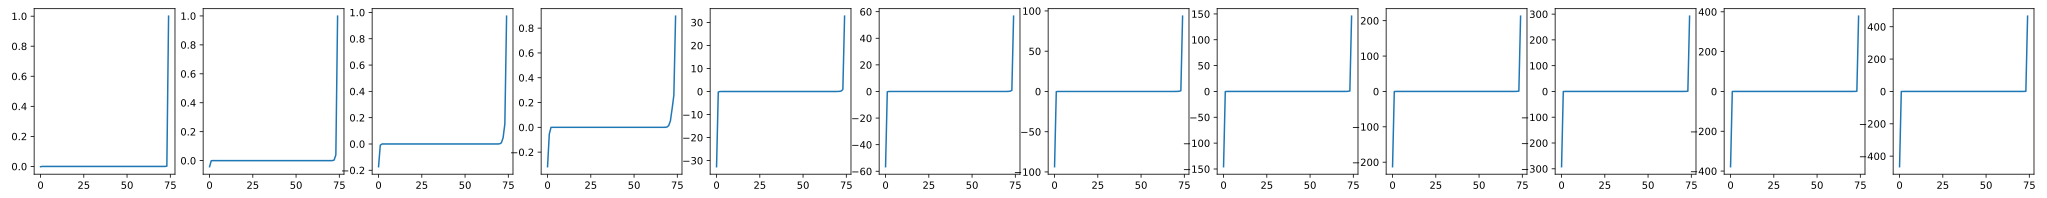

In [12]:
from qutip.sparse import eigh

ts = [50,100,150,200,250,300,350,400,450,500,550,600]
fig, axes = plt.subplots(1,len(ts),figsize = (len(ts)*3,3))
for i, t in enumerate(ts):
    values, vectors = eigh(r0[0].states[t].full())
    axes[i].plot(values)
